# 2D Ising Model — Monte Carlo Simulation

This notebook simulates the two-dimensional ferromagnetic Ising model on a square lattice using the **Metropolis Monte Carlo** algorithm. We measure four thermodynamic observables as functions of temperature and observe the paramagnetic-to-ferromagnetic phase transition near the exact critical temperature $T_c \approx 2.269\, J/k_B$.

## Theory

### The Ising Model

The Ising model is one of the most studied models in statistical mechanics. Each site $i$ of a lattice carries a spin $s_i \in \{-1, +1\}$. The energy of the system is given by the **Hamiltonian**:

$$
H = -J \sum_{\langle i,j \rangle} s_i s_j
$$

where $J > 0$ is the exchange coupling (ferromagnetic), the sum runs over all nearest-neighbour pairs, and we apply **periodic boundary conditions** so the lattice has no edges. We work in units where $J = k_B = 1$, so temperature $T$ is dimensionless.

### Thermodynamic Observables

In the canonical ensemble at temperature $T$, the observables we measure are:

| Observable | Formula | Physical meaning |
|---|---|---|
| Energy per spin | $\langle E \rangle / N$ | Mean energy density |
| Magnetisation per spin | $\langle |M| \rangle / N$ | Order parameter |
| Specific heat | $C_v = (\langle E^2 \rangle - \langle E \rangle^2) / (N T^2)$ | Energy fluctuations |
| Susceptibility | $\chi = (\langle M^2 \rangle - \langle M \rangle^2) / (N T)$ | Magnetisation fluctuations |

We use $|M|$ rather than $M$ because spontaneous symmetry breaking in a finite system causes the magnetisation to fluctuate between $\pm$ domains, so the time-averaged $\langle M \rangle \to 0$ even below $T_c$.

### Phase Transition

In 2D, the Ising model undergoes a continuous (second-order) phase transition at the **Onsager critical temperature**:

$$
T_c = \frac{2}{\ln(1 + \sqrt{2})} \approx 2.2692
$$

- **Below $T_c$**: spins spontaneously align → ferromagnetic phase, $\langle |M| \rangle / N \to 1$.
- **Above $T_c$**: thermal fluctuations destroy order → paramagnetic phase, $\langle |M| \rangle / N \to 0$.

Near $T_c$, the specific heat and susceptibility diverge in the thermodynamic limit ($L \to \infty$). For finite $L$ these quantities peak near $T_c$ with heights that scale as powers of $L$ — this is **finite-size scaling**.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Ising_model import run_ising_model

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.8,
    'lines.markersize': 4,
})

# Exact critical temperature (Onsager 1944)
TC = 2.0 / np.log(1.0 + np.sqrt(2.0))
print(f"Exact critical temperature: Tc = {TC:.6f}")

Exact critical temperature: Tc = 2.269185


## The Metropolis Algorithm

We use the **Metropolis-Hastings** algorithm to sample the Boltzmann distribution $P(\{s\}) \propto e^{-H/T}$:

1. Pick a spin $s_i$ at random.
2. Compute the energy change if the spin were flipped:  
   $\Delta E = 2 s_i \sum_{j \in \text{nn}(i)} s_j$
3. Accept the flip with probability $\min\!\left(1,\, e^{-\Delta E / T}\right)$.
4. Repeat $N = L^2$ times to complete one **Monte Carlo sweep**.

The implementation here uses **checkerboard (sublattice) updates**: the lattice is divided into two interleaved sublattices (black/white squares on a chess board). All sites within one sublattice can be updated simultaneously because they are not nearest neighbours of each other, enabling fully vectorised NumPy operations.

The lattice is **slowly cooled** from high to low temperature, carrying the spin configuration between temperature steps to reduce equilibration time.

## Single Lattice Simulation

We run a single simulation for $L = 36$, sweeping temperature from $T = 4.0$ down to $T = 0.5$ in steps of $\Delta T = 0.05$.

In [2]:
L = 36
MCS = 2000

print(f"Running Ising simulation: L={L}, MCS={MCS} per temperature step...")
df = run_ising_model(L=L, MCS=MCS, T_start=4.0, T_end=0.5, dT=0.05, seed=42)
print(f"Done. {len(df)} temperature points computed.")
df.tail()

Running Ising simulation: L=36, MCS=2000 per temperature step...
Done. 71 temperature points computed.


,T,M,E,Cv,chi
66,3.80,0.049026,-0.595207,0.204360,1.276859
67,3.85,0.047918,-0.585036,0.194582,1.185610
68,3.90,0.046713,-0.571900,0.177193,1.144758
69,3.95,0.046108,-0.564504,0.168397,1.101369
70,4.00,0.045249,-0.558685,0.169851,1.034145


## Thermodynamic Observables

The four plots below show the temperature dependence of the key observables. The vertical dashed line marks the exact Onsager critical temperature $T_c \approx 2.269$.

- **Magnetisation** drops sharply from ~1 to ~0 as $T$ crosses $T_c$.
- **Energy per spin** transitions from ~-2 (fully ordered ground state) to ~0 (disordered).
- **Specific heat** peaks near $T_c$; in the thermodynamic limit this diverges logarithmically.
- **Susceptibility** also peaks near $T_c$; it diverges as $L^{7/4}$ in the thermodynamic limit.

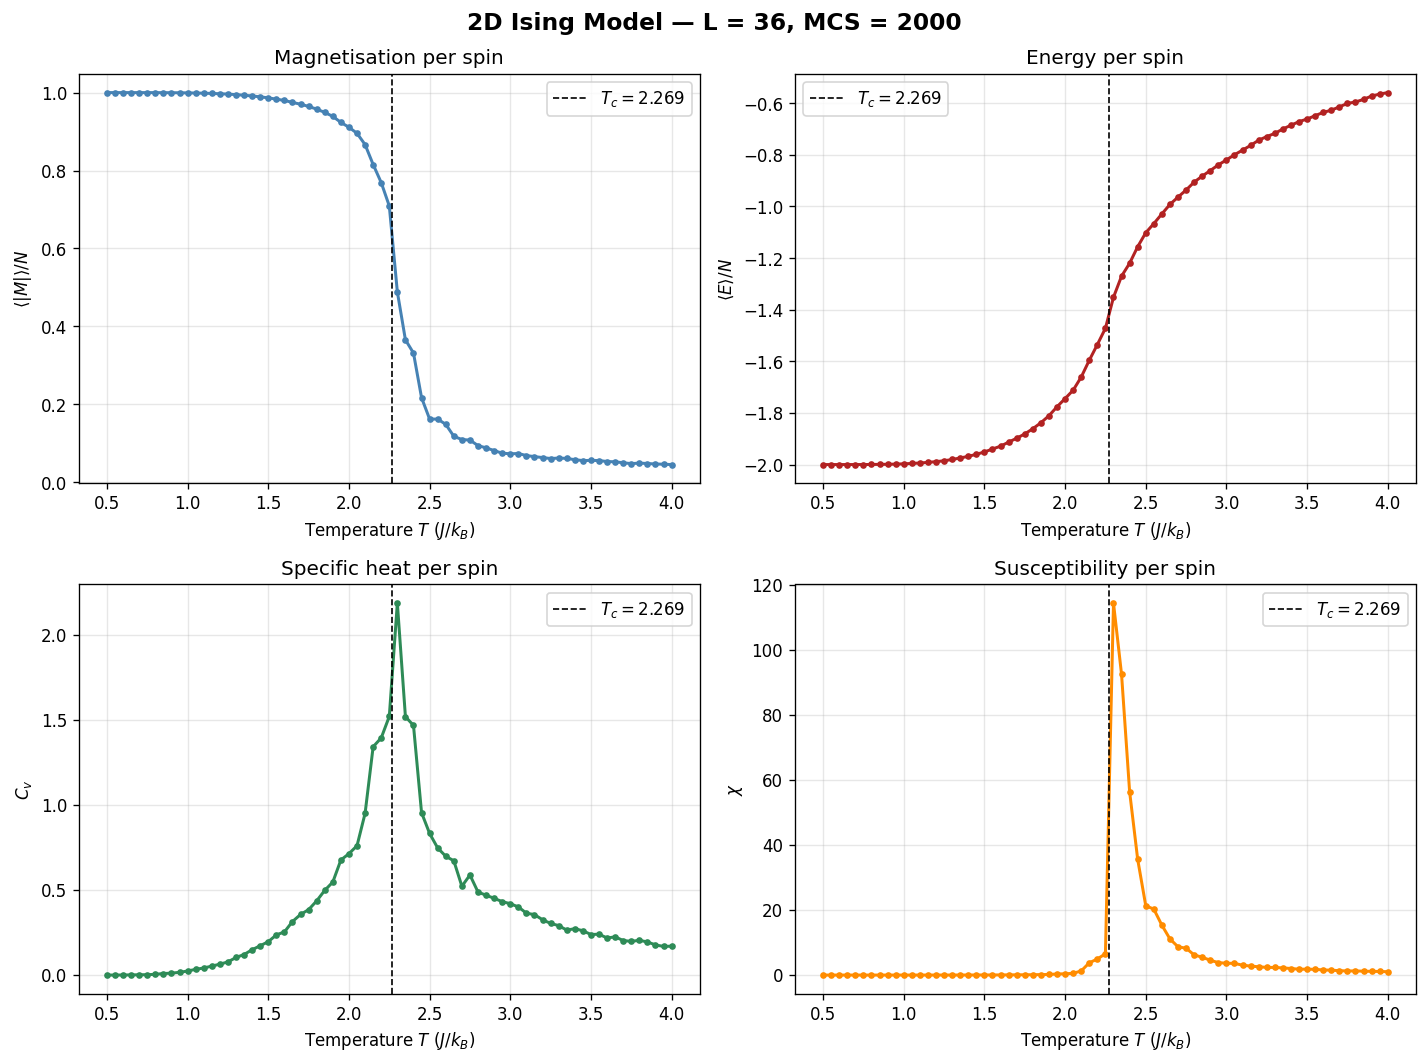

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(f"2D Ising Model — L = {L}, MCS = {MCS}", fontsize=14, fontweight='bold')

plot_cfg = [
    ('M',   r'$\langle|M|\rangle / N$',  'Magnetisation per spin',  'steelblue'),
    ('E',   r'$\langle E \rangle / N$',  'Energy per spin',         'firebrick'),
    ('Cv',  r'$C_v$',                    'Specific heat per spin',   'seagreen'),
    ('chi', r'$\chi$',                   'Susceptibility per spin',  'darkorange'),
]

for ax, (col, ylabel, title, color) in zip(axes.flat, plot_cfg):
    ax.plot(df['T'], df[col], 'o-', color=color, ms=3)
    ax.axvline(TC, color='black', linestyle='--', linewidth=1, label=f'$T_c = {TC:.3f}$')
    ax.set_xlabel('Temperature $T$ $(J/k_B)$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
# plt.savefig('observables_L36.png', bbox_inches='tight')
plt.show()

## Finite-Size Effects

A finite lattice rounds and shifts the singularities of the thermodynamic limit. Specifically:

- The magnetisation transition becomes smoother for smaller $L$.
- The peaks of $C_v$ and $\chi$ shift toward (but not exactly to) $T_c$ and grow with $L$.
- The **pseudo-critical temperature** $T_c(L)$ at which $\chi$ peaks approaches $T_c$ as
$T_c(L) \approx T_c + a\, L^{-1/\nu}$, with $\nu = 1$ for the 2D Ising universality class.

We now run simulations for three lattice sizes $L \in \{4, 12, 36, 100\}$ and overlay the results.

In [4]:
Ls  = [4, 12, 36, 100]
MCS = 2000
results = {}

for L in Ls:
    print(f"  L = {L:3d} ...", end=' ', flush=True)
    results[L] = run_ising_model(L=L, MCS=MCS, T_start=4.0, T_end=0.5, dT=0.05, seed=42)
    print("done")

print("All simulations complete.")

  L =   4 ... done
  L =  12 ... done
  L =  36 ... done
  L = 100 ... done
All simulations complete.


The plots below compare all three lattice sizes. Notice how larger $L$ gives a sharper transition and taller peaks in $C_v$ and $\chi$ — converging toward the true thermodynamic singularities.

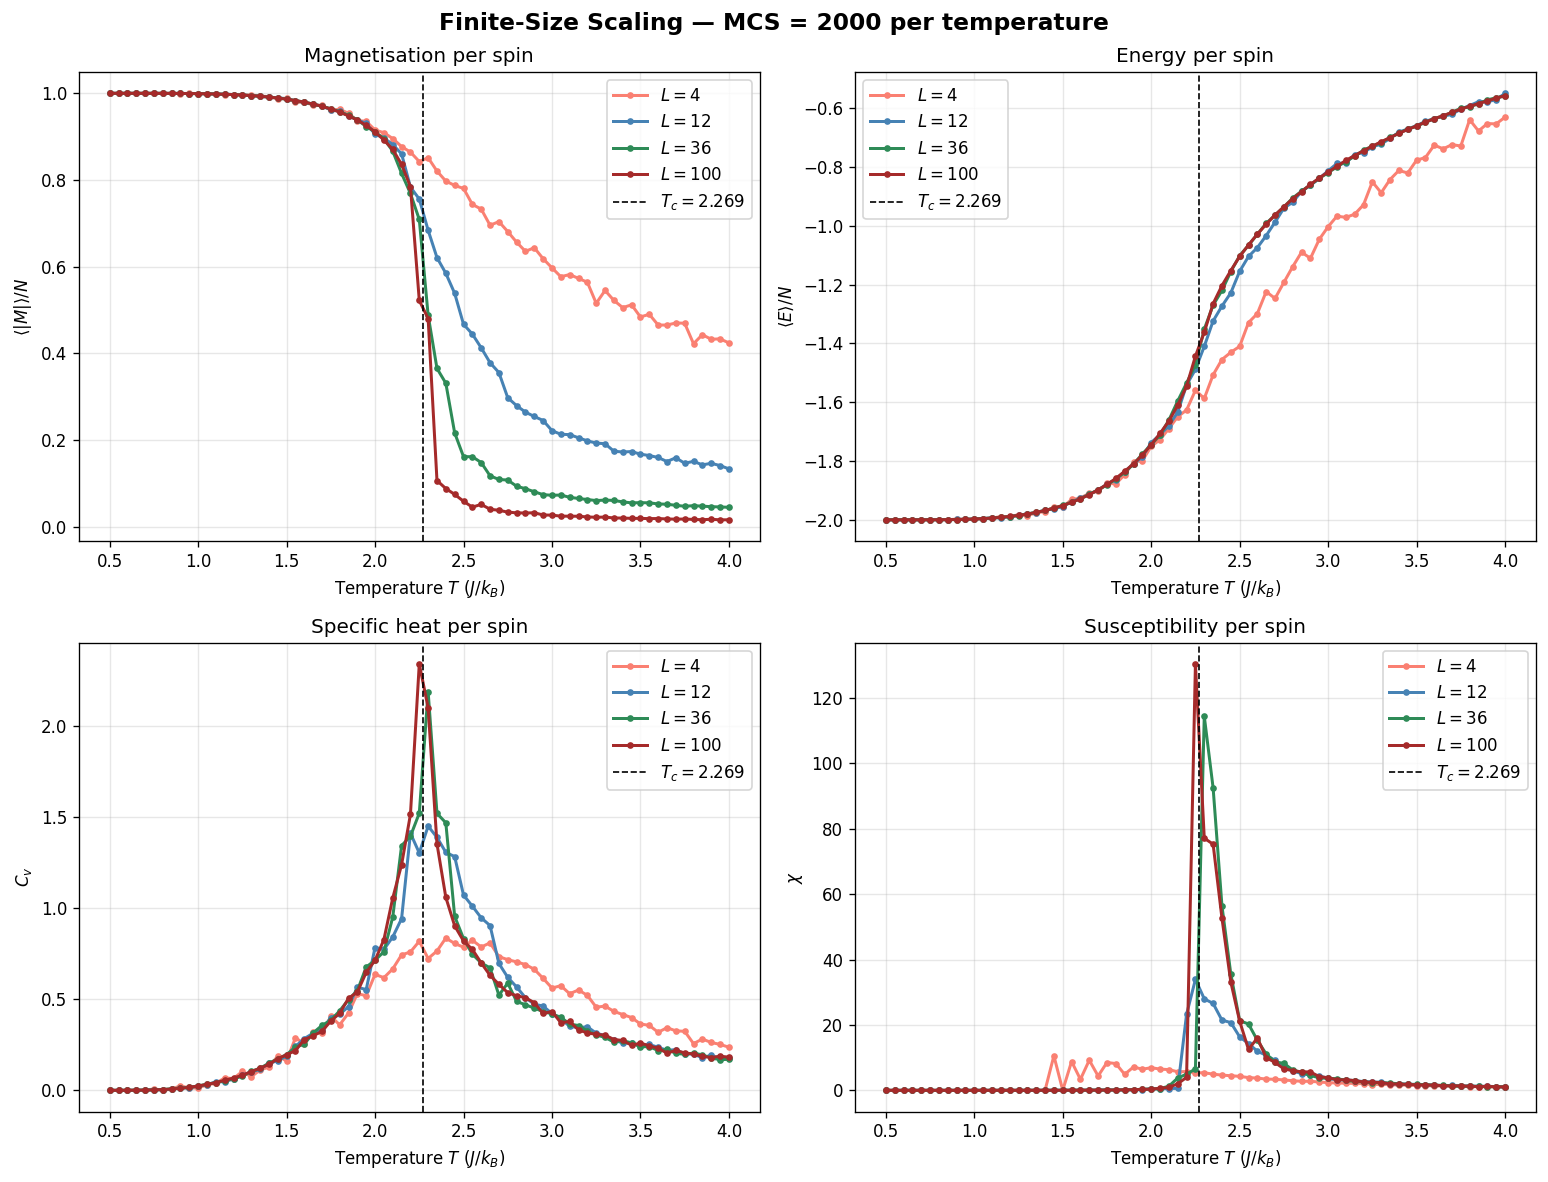

In [5]:
colors = {4: 'salmon', 12: 'steelblue', 36: 'seagreen', 100: 'brown'}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(f"Finite-Size Scaling — MCS = {MCS} per temperature", fontsize=14, fontweight='bold')

plot_cfg = [
    ('M',   r'$\langle|M|\rangle / N$', 'Magnetisation per spin'),
    ('E',   r'$\langle E \rangle / N$', 'Energy per spin'),
    ('Cv',  r'$C_v$',                   'Specific heat per spin'),
    ('chi', r'$\chi$',                  'Susceptibility per spin'),
]

for ax, (col, ylabel, title) in zip(axes.flat, plot_cfg):
    for L in Ls:
        d = results[L]
        ax.plot(d['T'], d[col], 'o-', color=colors[L], ms=3, label=f'$L = {L}$')
    ax.axvline(TC, color='black', linestyle='--', linewidth=1, label=f'$T_c = {TC:.3f}$')
    ax.set_xlabel('Temperature $T$ $(J/k_B)$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
# plt.savefig('finite_size_scaling.png', bbox_inches='tight')
plt.show()

## Peak Locations vs Lattice Size

We extract the pseudo-critical temperature $T_c(L)$ as the temperature at which the susceptibility $\chi$ is maximum for each $L$.

In [6]:
print(f"{'L':>4}  {'T_c(L) from χ peak':>20}  {'Cv peak':>10}  {'χ peak':>10}")
print('-' * 52)
for L in Ls:
    d = results[L]
    idx_chi = d['chi'].idxmax()
    idx_cv  = d['Cv'].idxmax()
    Tc_L    = d.loc[idx_chi, 'T']
    chi_max = d.loc[idx_chi, 'chi']
    Cv_max  = d.loc[idx_cv,  'Cv']
    print(f"{L:>4}  {Tc_L:>20.4f}  {Cv_max:>10.4f}  {chi_max:>10.4f}")

print(f"\nExact Tc = {TC:.6f}")

   L    T_c(L) from χ peak     Cv peak      χ peak
----------------------------------------------------
   4                1.4500      0.8350     10.5587
  12                2.2500      1.4491     33.9036
  36                2.3000      2.1864    114.3895
 100                2.2500      2.3392    130.4010

Exact Tc = 2.269185


## Conclusions

- The simulation correctly reproduces the ferromagnetic phase transition of the 2D Ising model.
- The magnetisation drops sharply near $T_c \approx 2.269$ and the specific heat and susceptibility diverge there.
- Finite-size effects are clearly visible: smaller lattices give broader, shorter, and slightly shifted peaks.
- Increasing MCS improves statistical accuracy (less noisy curves) at the cost of longer compute time.

**Further directions**:
- Implement the **Wolff cluster algorithm** for faster equilibration near $T_c$ (no critical slowing down).
- Perform a proper **finite-size scaling collapse** to extract critical exponents $\nu$, $\gamma$, $\beta$.
- Add an external magnetic field $h$ and study the equation of state $M(T, h)$.